# Telco Customer Churn Baseline

Goal: build a reproducible baseline model for predicting customer churn and select an operating threshold without leaking test-set information.

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)

## Load Data

In [2]:
DATA_PATH = Path("../data/telco-customer-churn.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("data/telco-customer-churn.csv")

raw_df = pd.read_csv(DATA_PATH)
raw_df.shape

(7043, 21)

In [3]:
raw_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Clean Data

`TotalCharges` arrives as text because new customers have a blank value. Those rows have `tenure == 0`, so they are valid customers before their first billed total. Keep them and set `TotalCharges` to `0.0`; only drop `TotalCharges` rows if any remaining missing values are not explained by zero tenure.

In [6]:
df = raw_df.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing_total = df["TotalCharges"].isna()
zero_tenure_missing_total = missing_total & df["tenure"].eq(0)
unexplained_missing_total = missing_total & ~df["tenure"].eq(0)

cleaning_summary = pd.DataFrame(
    {
        "check": [
            "rows before cleaning",
            "missing TotalCharges",
            "missing TotalCharges with tenure == 0",
            "unexplained missing TotalCharges",
        ],
        "count": [
            len(df),
            int(missing_total.sum()),
            int(zero_tenure_missing_total.sum()),
            int(unexplained_missing_total.sum()),
        ],
    }
)

# New customers have not accumulated billed total charges yet.
df.loc[zero_tenure_missing_total, "TotalCharges"] = 0.0
df = df.dropna(subset=["TotalCharges"]).copy()

cleaning_summary

,check,count
0,rows before cleaning,7043
1,missing TotalCharges,11
2,missing TotalCharges with tenure == 0,11
3,unexplained missing TotalCharges,0


In [7]:
missing_after_cleaning = df.isna().sum().to_frame("missing_count")
missing_after_cleaning[missing_after_cleaning["missing_count"] > 0]

,missing_count


In [8]:
df.shape

(7043, 21)

## Exploratory Analysis

The data is imbalanced, so churn-specific metrics matter more than overall accuracy.

In [9]:
y = df["Churn"].map({"No": 0, "Yes": 1})

class_balance = (
    y.value_counts()
    .rename(index={0: "No churn", 1: "Churn"})
    .to_frame("count")
)
class_balance["proportion"] = y.value_counts(normalize=True).rename(index={0: "No churn", 1: "Churn"})
class_balance

,count,proportion
Churn,,
No churn,5174,0.73463
Churn,1869,0.26537


In [10]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(["mean", "median", "std"])

tenure                   MonthlyCharges                     \
            mean median        std           mean  median        std   
Churn                                                                  
No     37.569965   38.0  24.113777      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123      74.441332  79.650  24.666053   

      TotalCharges                         
              mean    median          std  
Churn                                      
No     2549.911442  1679.525  2329.954215  
Yes    1531.796094   703.550  1890.822994

In [11]:
tenure_bins = [-1, 12, 24, 48, 72]
tenure_labels = ["0-12", "13-24", "25-48", "49-72"]

tenure_summary = pd.crosstab(
    pd.cut(df["tenure"], bins=tenure_bins, labels=tenure_labels),
    df["Churn"],
    normalize="index",
)
tenure_summary

Churn,No,Yes
tenure,,
0-12,0.525618,0.474382
13-24,0.712891,0.287109
25-48,0.796110,0.203890
49-72,0.904868,0.095132


In [12]:
def churn_rate_by(column):
    table = pd.crosstab(df[column], df["Churn"])
    rates = pd.crosstab(df[column], df["Churn"], normalize="index")
    return (
        rates.assign(customers=table.sum(axis=1))
        .rename(columns={"No": "no_churn_rate", "Yes": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )

for column in [
    "Contract",
    "PaymentMethod",
    "InternetService",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling",
    "SeniorCitizen",
    "Partner",
    "Dependents",
]:
    print(f"\n{column}")
    display(churn_rate_by(column))


Contract


Churn,no_churn_rate,churn_rate,customers
Contract,,,
Month-to-month,0.572903,0.427097,3875
One year,0.887305,0.112695,1473
Two year,0.971681,0.028319,1695



PaymentMethod


Churn,no_churn_rate,churn_rate,customers
PaymentMethod,,,
Electronic check,0.547146,0.452854,2365
Mailed check,0.808933,0.191067,1612
Bank transfer (automatic),0.832902,0.167098,1544
Credit card (automatic),0.847569,0.152431,1522



InternetService


...

Churn,no_churn_rate,churn_rate,customers
SeniorCitizen,,,
1,0.583187,0.416813,1142
0,0.763938,0.236062,5901



Partner


Churn,no_churn_rate,churn_rate,customers
Partner,,,
No,0.670420,0.329580,3641
Yes,0.803351,0.196649,3402



Dependents


Churn,no_churn_rate,churn_rate,customers
Dependents,,,
No,0.687209,0.312791,4933
Yes,0.845498,0.154502,2110


## Features and Splits

Use all non-ID predictors as the baseline feature set. Split data into train, validation, and test sets. Model and threshold selection use only train/validation data; the test set is reserved for one final evaluation.

In [13]:
TARGET = "Churn"
ID_COLUMNS = ["customerID"]
NUMERIC_FEATURES = ["tenure", "MonthlyCharges", "TotalCharges"]
FEATURES = [column for column in df.columns if column not in ID_COLUMNS + [TARGET]]
CATEGORICAL_FEATURES = [column for column in FEATURES if column not in NUMERIC_FEATURES]

X = df[FEATURES]
y = df[TARGET].map({"No": 0, "Yes": 1})

feature_summary = pd.DataFrame(
    {
        "feature": FEATURES,
        "type": ["numeric" if column in NUMERIC_FEATURES else "categorical" for column in FEATURES],
    }
)
feature_summary

,feature,type
0,gender,categorical
1,SeniorCitizen,categorical
2,Partner,categorical
3,Dependents,categorical
4,tenure,numeric
5,PhoneService,categorical
6,MultipleLines,categorical
7,InternetService,categorical
8,OnlineSecurity,categorical
9,OnlineBackup,categorical


In [14]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(X_train), len(X_val), len(X_test)],
        "churn_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)
split_summary

,split,rows,churn_rate
0,train,4225,0.265325
1,validation,1409,0.265436
2,test,1409,0.265436


## Modeling Helpers

In [15]:
def make_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), NUMERIC_FEATURES),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ]
    )


def make_model(model_name):
    if model_name == "Logistic Regression":
        classifier = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    elif model_name == "Balanced Logistic Regression":
        classifier = LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    elif model_name == "Random Forest":
        classifier = RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return Pipeline(
        steps=[
            ("preprocessor", make_preprocessor()),
            ("classifier", classifier),
        ]
    )


MODEL_NAMES = [
    "Logistic Regression",
    "Balanced Logistic Regression",
    "Random Forest",
]

In [16]:
def evaluate_predictions(model_name, y_true, y_pred, y_proba, threshold):
    return {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
        "brier_score": brier_score_loss(y_true, y_proba),
    }


def evaluate_model(model_name, model, X_data, y_true, threshold=0.50):
    y_proba = model.predict_proba(X_data)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    return evaluate_predictions(model_name, y_true, y_pred, y_proba, threshold)

## Baseline Model Comparison

First compare models at the default `0.50` threshold on validation data, then search thresholds on validation data only.

In [17]:
fitted_models = {}
validation_rows = []

for model_name in MODEL_NAMES:
    model = make_model(model_name)
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    validation_rows.append(evaluate_model(model_name, model, X_val, y_val, threshold=0.50))

validation_results = pd.DataFrame(validation_rows).sort_values("f1", ascending=False)
validation_results

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
1,Balanced Logistic Regression,0.5,0.748048,0.516637,0.788770,0.624339,0.836293,0.642548,0.167935
0,Logistic Regression,0.5,0.802697,0.657895,0.534759,0.589971,0.836047,0.642352,0.138073
2,Random Forest,0.5,0.792051,0.657588,0.451872,0.535658,0.838070,0.637498,0.137957


In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "precision": "precision",
}

cv_rows = []
for model_name in MODEL_NAMES:
    cv_scores = cross_validate(
        make_model(model_name),
        X_train_val,
        y_train_val,
        cv=cv,
        scoring=scoring,
    )
    row = {"model": model_name}
    for metric in scoring:
        values = cv_scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_std"] = values.std()
    cv_rows.append(row)

cv_results = pd.DataFrame(cv_rows).sort_values("f1_mean", ascending=False)
cv_results

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,recall_mean,recall_std,precision_mean,precision_std
1,Balanced Logistic Regression,0.845994,0.012394,0.660075,0.019565,0.628250,0.023137,0.801338,0.037933,0.516912,0.018692
0,Logistic Regression,0.846149,0.012562,0.661493,0.019374,0.592412,0.029782,0.543813,0.040885,0.652094,0.025612
2,Random Forest,0.846996,0.009003,0.661815,0.018776,0.570655,0.014036,0.489632,0.010276,0.684383,0.028296


## Validation Threshold Search

Use validation F1 as the temporary selection rule. If the business objective changes, replace this with a cost-based metric or a required recall/precision constraint.

In [19]:
thresholds = np.round(np.arange(0.20, 0.71, 0.05), 2)
threshold_rows = []

for model_name, model in fitted_models.items():
    y_val_proba = model.predict_proba(X_val)[:, 1]
    for threshold in thresholds:
        y_val_pred = (y_val_proba >= threshold).astype(int)
        threshold_rows.append(
            evaluate_predictions(model_name, y_val, y_val_pred, y_val_proba, threshold)
        )

threshold_results = pd.DataFrame(threshold_rows).sort_values(
    ["f1", "recall", "precision"],
    ascending=False,
)
threshold_results.head(12)

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
26,Random Forest,0.40,0.803407,0.625974,0.644385,0.635046,0.838070,0.637498,0.137957
25,Random Forest,0.35,0.779986,0.568376,0.711230,0.631829,0.838070,0.637498,0.137957
3,Logistic Regression,0.35,0.778566,0.566524,0.705882,0.628571,0.836047,0.642352,0.138073
2,Logistic Regression,0.30,0.762952,0.538314,0.751337,0.627232,0.836047,0.642352,0.138073
18,Balanced Logistic Regression,0.55,0.762243,0.537572,0.745989,0.624860,0.836293,0.642548,0.167935
19,Balanced Logistic Regression,0.60,0.776437,0.563441,0.700535,0.624553,0.836293,0.642548,0.167935
17,Balanced Logistic Regression,0.50,0.748048,0.516637,0.788770,0.624339,0.836293,0.642548,0.167935
1,Logistic Regression,0.25,0.740241,0.506757,0.802139,0.621118,0.836047,0.642352,0.138073
24,Random Forest,0.30,0.751597,0.521978,0.762032,0.619565,0.838070,0.637498,0.137957
20,Balanced Logistic Regression,0.65,0.789922,0.596535,0.644385,0.619537,0.836293,0.642548,0.167935


## Why Thresholds Change Model Ranking

Each model produces a churn probability. The threshold converts that probability into a yes/no churn prediction.

A threshold of `0.50` is only a default. It is not automatically the best business cutoff. Lowering the threshold catches more churners but creates more false positives. Raising it creates fewer false positives but misses more churners.

In [20]:
default_threshold_ranking = (
    threshold_results[threshold_results["threshold"].eq(0.50)]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

default_threshold_ranking

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Balanced Logistic Regression,0.5,0.748048,0.516637,0.788770,0.624339,0.836293,0.642548,0.167935
1,Logistic Regression,0.5,0.802697,0.657895,0.534759,0.589971,0.836047,0.642352,0.138073
2,Random Forest,0.5,0.792051,0.657588,0.451872,0.535658,0.838070,0.637498,0.137957


In [21]:
best_threshold_by_model = (
    threshold_results.loc[threshold_results.groupby("model")["f1"].idxmax()]
    .sort_values("f1", ascending=False)
    .reset_index(drop=True)
)

best_threshold_by_model

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Random Forest,0.40,0.803407,0.625974,0.644385,0.635046,0.838070,0.637498,0.137957
1,Logistic Regression,0.35,0.778566,0.566524,0.705882,0.628571,0.836047,0.642352,0.138073
2,Balanced Logistic Regression,0.55,0.762243,0.537572,0.745989,0.624860,0.836293,0.642548,0.167935


The two tables above show the core idea:

- At the default `0.50` threshold, Balanced Logistic Regression has the best F1 because it predicts churn more aggressively.
- After each model gets its own threshold, Random Forest rises to the top because a lower threshold gives it a better precision/recall balance.

In [22]:
threshold_detail_rows = []
thresholds_to_compare = [0.30, 0.40, 0.50, 0.60]

for model_name, model in fitted_models.items():
    y_val_proba = model.predict_proba(X_val)[:, 1]
    for threshold in thresholds_to_compare:
        y_val_pred = (y_val_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()
        threshold_detail_rows.append(
            {
                "model": model_name,
                "threshold": threshold,
                "predicted_churn_customers": int(y_val_pred.sum()),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "false_negatives": int(fn),
                "precision": precision_score(y_val, y_val_pred, zero_division=0),
                "recall": recall_score(y_val, y_val_pred, zero_division=0),
                "f1": f1_score(y_val, y_val_pred, zero_division=0),
            }
        )

threshold_details = pd.DataFrame(threshold_detail_rows)
threshold_details.sort_values(["model", "threshold"])

,model,threshold,predicted_churn_customers,true_positives,false_positives,false_negatives,precision,recall,f1
4,Balanced Logistic Regression,0.3,812,341,471,33,0.419951,0.911765,0.575042
5,Balanced Logistic Regression,0.4,693,318,375,56,0.458874,0.850267,0.596064
6,Balanced Logistic Regression,0.5,571,295,276,79,0.516637,0.788770,0.624339
7,Balanced Logistic Regression,0.6,465,262,203,112,0.563441,0.700535,0.624553
0,Logistic Regression,0.3,522,281,241,93,0.538314,0.751337,0.627232
1,Logistic Regression,0.4,405,241,164,133,0.595062,0.644385,0.618742
2,Logistic Regression,0.5,304,200,104,174,0.657895,0.534759,0.589971
3,Logistic Regression,0.6,199,141,58,233,0.708543,0.377005,0.492147
8,Random Forest,0.3,546,285,261,89,0.521978,0.762032,0.619565
9,Random Forest,0.4,385,241,144,133,0.625974,0.644385,0.635046


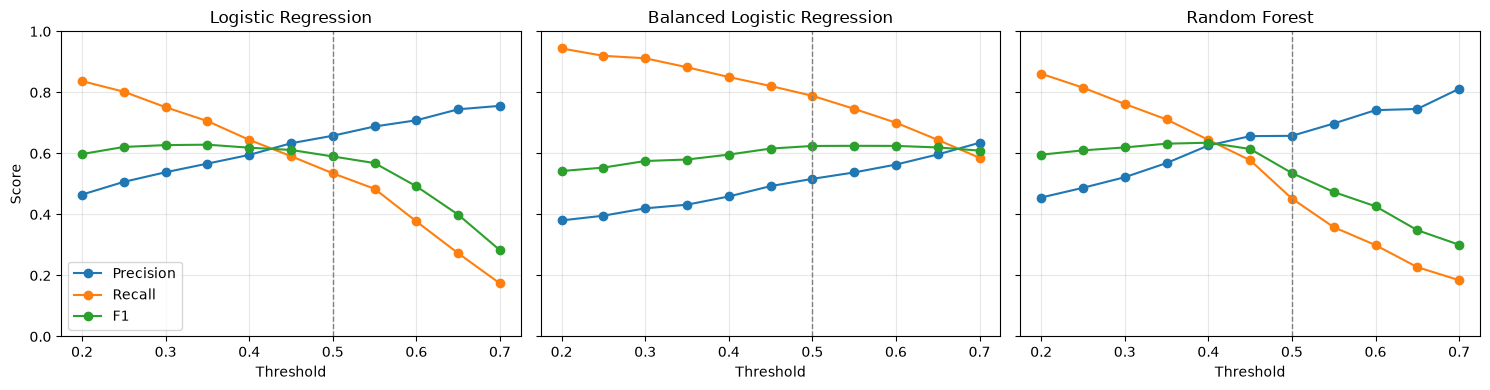

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, model_name in zip(axes, MODEL_NAMES):
    model_thresholds = threshold_results[threshold_results["model"].eq(model_name)].sort_values("threshold")
    ax.plot(model_thresholds["threshold"], model_thresholds["precision"], marker="o", label="Precision")
    ax.plot(model_thresholds["threshold"], model_thresholds["recall"], marker="o", label="Recall")
    ax.plot(model_thresholds["threshold"], model_thresholds["f1"], marker="o", label="F1")
    ax.axvline(0.50, color="gray", linestyle="--", linewidth=1)
    ax.set_title(model_name)
    ax.set_xlabel("Threshold")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Score")
axes[0].legend(loc="lower left")
plt.tight_layout()

The plot is the easiest way to read the tradeoff:

- As threshold increases, precision usually rises.
- As threshold increases, recall usually falls.
- F1 peaks where precision and recall are most balanced for that model.

In [24]:
score_summary_rows = []

for model_name, model in fitted_models.items():
    y_val_proba = pd.Series(model.predict_proba(X_val)[:, 1], index=y_val.index)
    for actual_value, actual_label in [(0, "No churn"), (1, "Churn")]:
        scores = y_val_proba[y_val.eq(actual_value)]
        score_summary_rows.append(
            {
                "model": model_name,
                "actual_class": actual_label,
                "customers": int(scores.size),
                "mean_score": scores.mean(),
                "median_score": scores.median(),
                "p25_score": scores.quantile(0.25),
                "p75_score": scores.quantile(0.75),
            }
        )

score_summary = pd.DataFrame(score_summary_rows)
score_summary.sort_values(["model", "actual_class"])

,model,actual_class,customers,mean_score,median_score,p25_score,p75_score
3,Balanced Logistic Regression,Churn,374,0.668630,0.759060,0.542839,0.838992
2,Balanced Logistic Regression,No churn,1035,0.316066,0.259818,0.065639,0.526877
1,Logistic Regression,Churn,374,0.477892,0.536399,0.300419,0.663257
0,Logistic Regression,No churn,1035,0.182670,0.106820,0.024560,0.284809
5,Random Forest,Churn,374,0.470102,0.477497,0.317374,0.629530
4,Random Forest,No churn,1035,0.189844,0.134492,0.034631,0.302636


This score summary explains why model rankings can move. Two models can rank customers similarly but place their probabilities on different scales. A `0.50` threshold can be aggressive for one model and conservative for another.

That is why we treat the model and threshold as a pair.

In [25]:
selected = threshold_results.iloc[0]
selected_model_name = selected["model"]
selected_threshold = float(selected["threshold"])

selected.to_frame("selected_value")

,selected_value
model,Random Forest
threshold,0.4
accuracy,0.803407
precision,0.625974
recall,0.644385
f1,0.635046
roc_auc,0.83807
pr_auc,0.637498
brier_score,0.137957


## Final Test Evaluation

Refit the selected model family on train plus validation data, then evaluate the selected threshold once on the held-out test set.

In [26]:
final_model = make_model(selected_model_name)
final_model.fit(X_train_val, y_train_val)

test_proba = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= selected_threshold).astype(int)

test_results = pd.DataFrame(
    [
        evaluate_predictions(
            selected_model_name,
            y_test,
            test_pred,
            test_proba,
            selected_threshold,
        )
    ]
)
test_results

,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score
0,Random Forest,0.4,0.787083,0.591584,0.639037,0.614396,0.84358,0.653629,0.135859


In [27]:
confusion = confusion_matrix(y_test, test_pred)
confusion_df = pd.DataFrame(
    confusion,
    index=["actual_no_churn", "actual_churn"],
    columns=["predicted_no_churn", "predicted_churn"],
)
confusion_df

,predicted_no_churn,predicted_churn
actual_no_churn,870,165
actual_churn,135,239


In [28]:
print(classification_report(y_test, test_pred, target_names=["No churn", "Churn"]))

              precision    recall  f1-score   support

    No churn       0.87      0.84      0.85      1035
       Churn       0.59      0.64      0.61       374

    accuracy                           0.79      1409
   macro avg       0.73      0.74      0.73      1409
weighted avg       0.79      0.79      0.79      1409



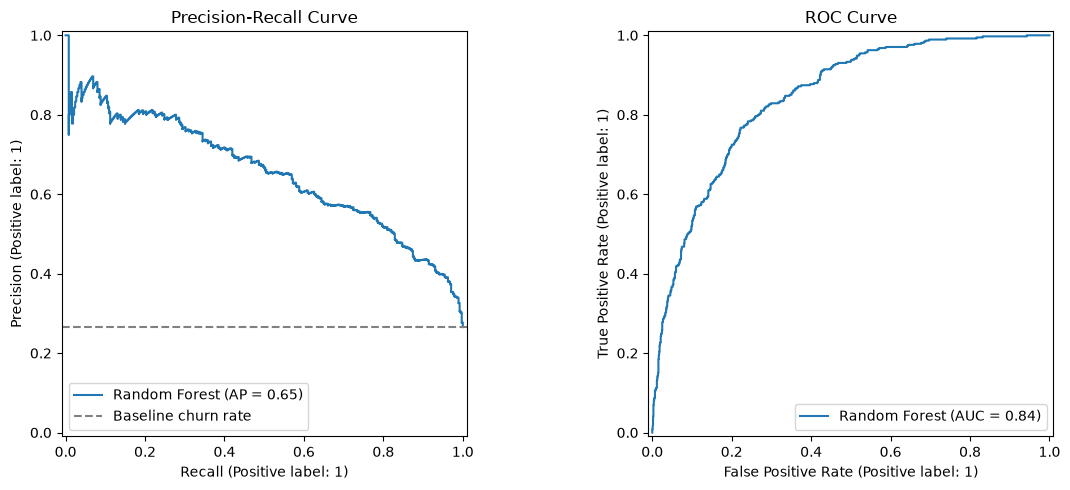

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    test_proba,
    name=selected_model_name,
    ax=axes[0],
)
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="Baseline churn rate")
axes[0].legend(loc="lower left")
axes[0].set_title("Precision-Recall Curve")

RocCurveDisplay.from_predictions(
    y_test,
    test_proba,
    name=selected_model_name,
    ax=axes[1],
)
axes[1].set_title("ROC Curve")

plt.tight_layout()

## Model Interpretation

For linear models, coefficient magnitudes are useful for directional inspection, not causal claims. For tree models, impurity-based importances are a quick first look and should eventually be checked with permutation importance. `tenure`, `MonthlyCharges`, and `TotalCharges` are related, so interpret them together.

In [30]:
classifier = final_model.named_steps["classifier"]
preprocessor = final_model.named_steps["preprocessor"]

if hasattr(classifier, "coef_"):
    coefficient_table = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),
            "coefficient": classifier.coef_[0],
        }
    )
    coefficient_table["abs_coefficient"] = coefficient_table["coefficient"].abs()

    print("Highest positive churn-risk coefficients")
    display(coefficient_table.sort_values("coefficient", ascending=False).head(12))

    print("Highest negative churn-risk coefficients")
    display(coefficient_table.sort_values("coefficient", ascending=True).head(12))
else:
    importance_table = pd.DataFrame(
        {
            "feature": preprocessor.get_feature_names_out(),
            "importance": classifier.feature_importances_,
        }
    ).sort_values("importance", ascending=False)
    display(importance_table.head(20))

,feature,importance
0,num__tenure,0.146895
37,cat__Contract_Month-to-month,0.121250
2,num__TotalCharges,0.111588
1,num__MonthlyCharges,0.070274
19,cat__OnlineSecurity_No,0.066152
17,cat__InternetService_Fiber optic,0.055500
28,cat__TechSupport_No,0.053809
44,cat__PaymentMethod_Electronic check,0.046796
39,cat__Contract_Two year,0.035942
16,cat__InternetService_DSL,0.021485


## Correction Pass Summary

- Kept valid zero-tenure customers by setting missing `TotalCharges` to `0.0`.
- Used all non-ID predictors for the baseline instead of a reduced hand-picked subset.
- Added train, validation, and test separation.
- Selected model and threshold using validation data only.
- Reserved the test set for one final evaluation.
- Added ROC-AUC, PR-AUC, Brier score, confusion matrix, and threshold-aware metrics.